## What is this piece of medical equipment?

In [2]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [3]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq fastai

In [4]:
import fastai
print(fastai.__version__)

2.8.7


## Step 1: Download images of medical equipment

In [5]:
!pip install ddgs

In [6]:
# to ensure that the install was successful
!pip show ddgs

Name: ddgs
Version: 9.14.4
Summary: Dux Distributed Global Search. A metasearch library that aggregates results from diverse web search services.
Home-page: https://github.com/deedy5/ddgs
Author: deedy5
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: click, fake-useragent, httpx, lxml, primp
Required-by: 


Set a list of equipment to search for:

In [7]:
from ddgs import DDGS 
from fastcore.all import *

equipment = ["stethoscope", "wheelchair", "syringe", "hospital bed", "defibrillator", "x-ray machine"]

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json

Pick a specific piece of equipment to search for now and use later. We'll start by getting URLs from a search:

In [17]:
urls = search_images('defibrillator', max_images=1)
urls[0]

'https://firstmedicalint.com/cdn/shop/files/ZollR.png?v=1704316526&width=1445'

...and then download a URL and take a look at it:

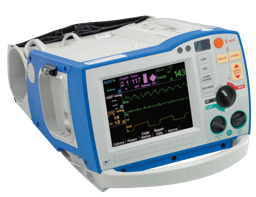

In [18]:
from fastdownload import download_url

dest = 'equip.jpg'
download_url(urls[0], dest, show_progress=False)

from fastai.vision.all import *
im = Image.open(dest)
im.to_thumb(256,256)

The image looks correct, so now let's loop through the list to grab some examples and save each to a different folder:

In [11]:
path = Path('medical_equip')

for equip in equipment:
    dest = (path/equip)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{equip} photo'))
    time.sleep(5)
    
    resize_images(path/equip, max_size=400, dest=path/equip)

## Step 2: Train our model

Some photos might not download correctly which could cause our model training to fail, so we'll remove them:

In [12]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

To train a model, we'll need `DataLoaders`, which is an object that contains a *training set* (the images used to create a model) and a *validation set* (the images used to check the accuracy of a model -- not used during training). In `fastai` we can create that easily using a `DataBlock`, and view sample images from it:

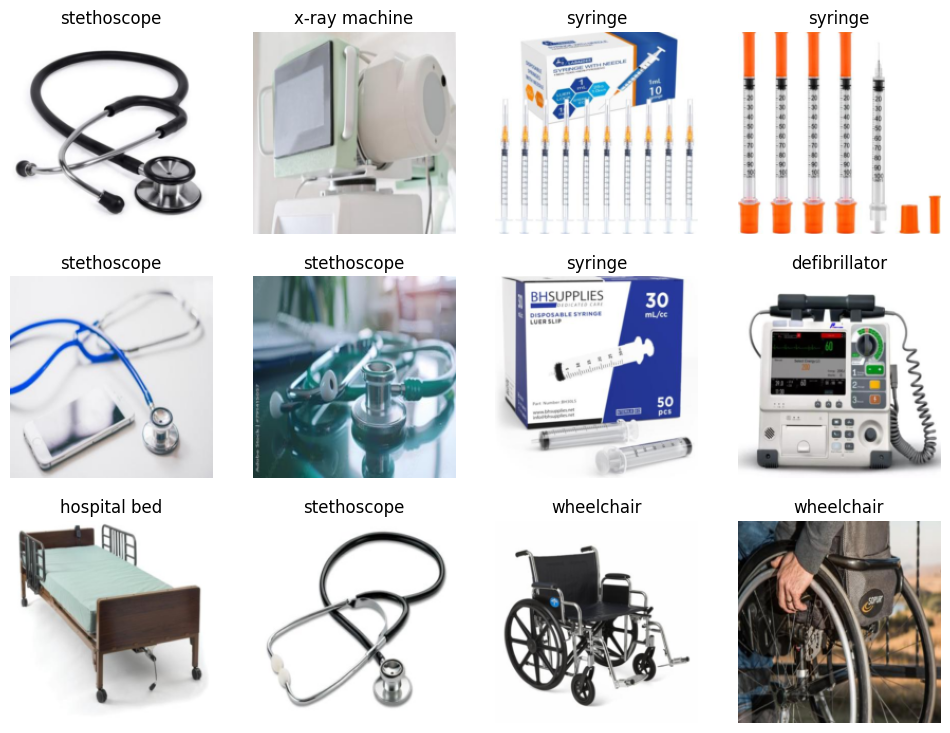

In [13]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=12)

Here what each of the `DataBlock` parameters means:

    blocks=(ImageBlock, CategoryBlock),

The inputs to our model are images, and the outputs are categories.

    get_items=get_image_files, 

To find all the inputs to our model, run the `get_image_files` function (which returns a list of all image files in a path).

    splitter=RandomSplitter(valid_pct=0.2, seed=42),

Split the data into training and validation sets randomly, using 20% of the data for the validation set.

    get_y=parent_label,

The labels (`y` values) is the name of the `parent` of each file (i.e. the name of the folder they're in).

    item_tfms=[Resize(192, method='squish')]

Before training, resize each image to 192x192 pixels by "squishing" it (as opposed to cropping it).

Now we're ready to train our model. The fastest widely used computer vision model is `resnet18`. You can train this in a few minutes, even on a CPU! (On a GPU, it generally takes under 10 seconds...)

`fastai` comes with a helpful `fine_tune()` method which automatically uses best practices for fine tuning a pre-trained model, so we'll use that.

In [14]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,2.019248,0.444960,0.128571,00:02


epoch,train_loss,valid_loss,error_rate,time
0,0.514466,0.169000,0.042857,00:01
1,0.339490,0.094181,0.042857,00:01
2,0.250491,0.107616,0.028571,00:01


## Step 3: Use our model (and build your own!)

Let's see what our model thinks about that piece of equipment that we downloaded at the start:

In [19]:
equip,_,probs = learn.predict(PILImage.create('equip.jpg'))

print(f"This piece of medical equipment is a {equip}.")

# Below are ways to check if accuracy and confused if it does not correctly
# recognize the image

# print(f"Probability: {probs[0]:.4f}")
# print(f"Confidence: {probs[0]:.2%}")

# interp = ClassificationInterpretation.from_learner(learn)
# interp.most_confused(min_val=1)

This piece of medical equipment is a defibrillator.


This can be used to check the folder of a specific piece of equipment
to see the images to troubleshoot

35


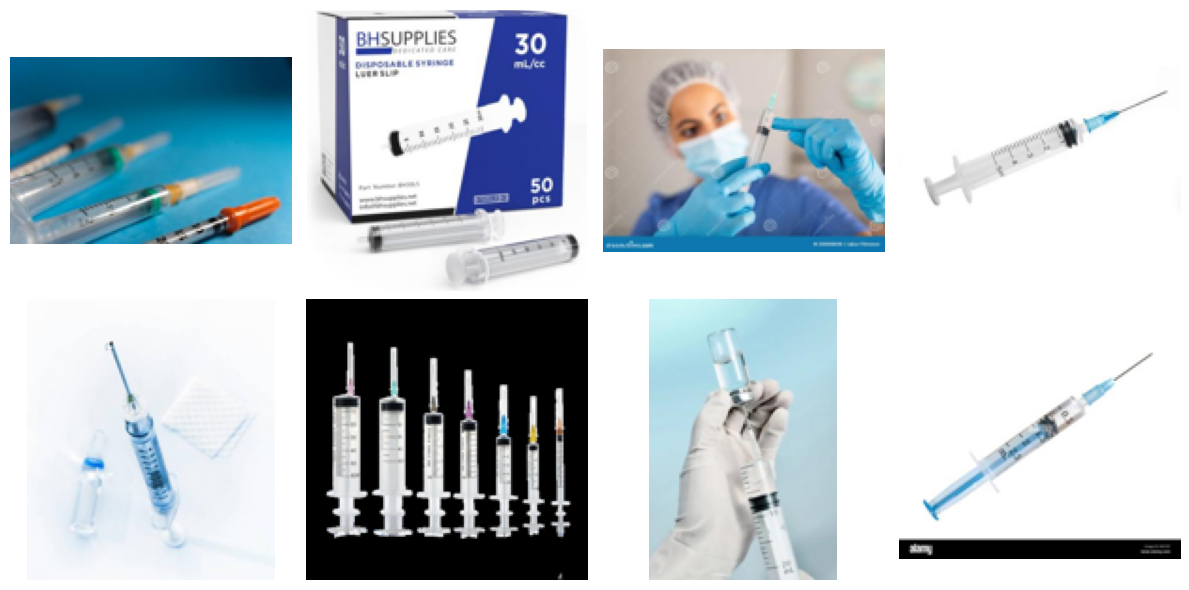

In [16]:
import matplotlib.pyplot as plt
import numpy as np

syringe_files = get_image_files(path/'syringe')
print(len(syringe_files))

fig, axes = plt.subplots(2, 4, figsize=(12,6))
for ax, f in zip(axes.flatten(), syringe_files[:8]):
    img = PILImage.create(f).to_thumb(150,150)
    ax.imshow(np.array(img))
    ax.axis('off')
plt.tight_layout()
plt.show()